In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import sys
sys.path.append('..')

from solar_irradiance.datamodules.cloud_mask import CloudMask
from solar_irradiance.datamodules.sun_mask import SunMask

In [3]:
img = np.asarray(Image.open('./images/images/20140509_200700.jpg'))

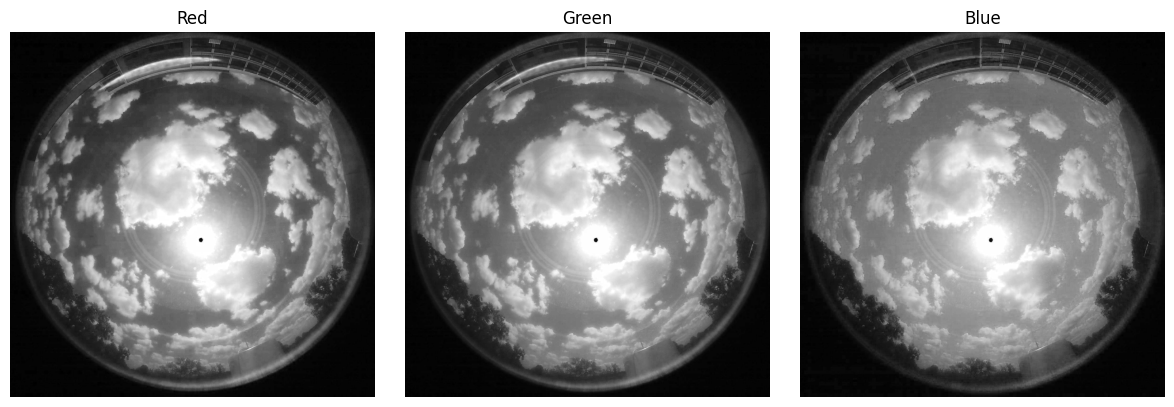

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for idx, color in enumerate(['Red', 'Green', 'Blue']):
    ax[idx].imshow(img[..., idx], cmap='gray')
    ax[idx].axis('off')
    ax[idx].set_title(color)
    
plt.tight_layout()

### Sun Mask

In [128]:
LATITUDE = 38.642
LONGITUDE = -121.148
CAMERA_ORIENTATION_COMPENSATION = 165
FOCAL_LENGTH = 0.48

sun_mask_gen = SunMask(
    latitude=LATITUDE,
    longitude=LONGITUDE,
    camera_orientation_compensation=CAMERA_ORIENTATION_COMPENSATION,
    focal_length=FOCAL_LENGTH,
)

In [129]:
sun_mask = sun_mask_gen((1536, 1536), timestamp='20140509_200700')

(-0.5, 1535.5, 1535.5, -0.5)

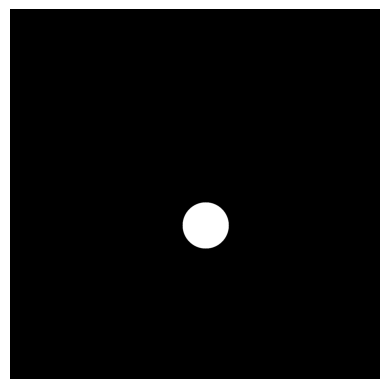

In [130]:
plt.imshow(sun_mask, cmap='gray')
plt.axis('off')

### Cloud Channel

In [131]:
cm_mask_gen = CloudMask(shape=(1536, 1536), method='normalized_blue_red_ratio')

In [132]:
cm_mask = cm_mask_gen(img)

(-0.5, 1535.5, 1535.5, -0.5)

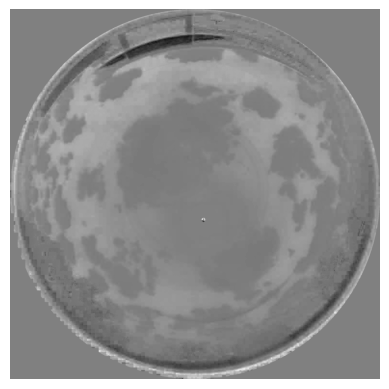

In [133]:
plt.imshow(cm_mask, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

### Optical Flow

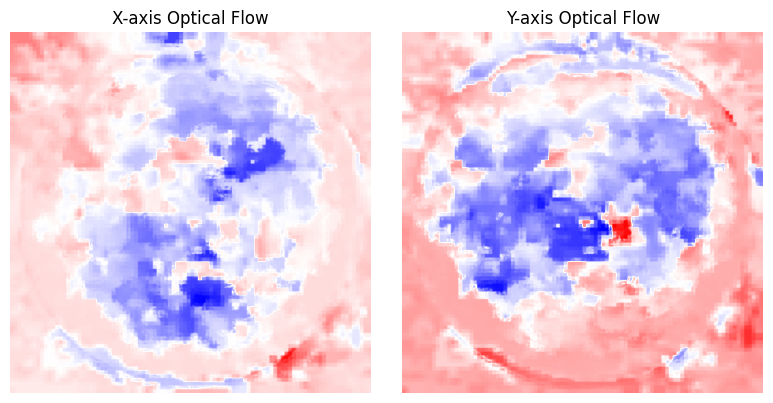

In [12]:
dis_of = cv2.DISOpticalFlow_create(preset=cv2.DISOPTICAL_FLOW_PRESET_ULTRAFAST)
flow = None

imgs = [
    './images/images/20140509_195200.jpg',
    './images/images/20140509_195700.jpg',
    './images/images/20140509_200200.jpg',
    './images/images/20140509_200700.jpg',
]

for idx in range(1, 4):
    img1_grey = np.asarray(Image.open(imgs[idx-1]).convert('L'))
    img2_grey = np.asarray(Image.open(imgs[idx]).convert('L'))

    flow = dis_of.calc(img1_grey, img2_grey, flow)
    
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for idx, label in enumerate(['X-axis Optical Flow', 'Y-axis Optical Flow']):
    ax[idx].imshow(flow[..., idx], cmap='bwr')
    ax[idx].axis('off')
    ax[idx].set_title(label)
    
plt.tight_layout()

# Raspberry Pi evaluation

In [83]:
rpi_4B_inference = [0.0934, 0.1273, 0.2608, 0.4450, 1.0586]
rpi_4B_inference_std = [0.0043, 0.0043, 0.0022, 0.0076, 0.0185]
rpi_5_inference = [0.0330, 0.0504, 0.1021, 0.1863, 0.4554]
rpi_5_inference_std = [0.0018, 0.0045, 0.0093, 0.0087, 0.0059]

rpi_4B_preprocessing = [0.0212, 0.0222, 0.0257, 0.0434, 0.0788]
rpi_4B_preprocessing_std = [0.0021, 0.0010, 0.0060, 0.0085, 0.0078]
rpi_5_preprocessing = [0.0053, 0.0079, 0.0136, 0.0238, 0.0475]
rpi_5_preprocessing_std = [0.0003, 0.0011, 0.0016, 0.0023, 0.0034]

rpi_4B_sun_mask = [0.0148, 0.0150, 0.0156, 0.0172, 0.0216]
rpi_4B_sun_mask_std = [0.0003, 0.0002, 0.0002, 0.0006, 0.0009]
rpi_5_sun_mask = [0.0048, 0.0061, 0.0070, 0.0079, 0.0108]
rpi_5_sun_mask_std = [0.0004, 0.0011, 0.0010, 0.0008, 0.0007]

rpi_4B_irradiance_channel = [0.0001, 0.0001, 0.0002, 0.0009, 0.0024]
rpi_4B_irradiance_channel_std = [0.0000, 0.0000, 0.0000, 0.0001, 0.0001]
rpi_5_irradiance_channel = [0.0000, 0.0001, 0.0001, 0.0002, 0.0008]
rpi_5_irradiance_channel_std = [0.0000, 0.0000, 0.0000, 0.0001, 0.0001]

rpi_4B_cloud_channel = [0.0008, 0.0014, 0.0039, 0.0081, 0.0200]
rpi_4B_cloud_channel_std = [0.0000, 0.0001, 0.0002, 0.0005, 0.0009]
rpi_5_cloud_channel = [0.0003, 0.0007, 0.0016, 0.0035, 0.0112]
rpi_5_cloud_channel_std = [0.0000, 0.0001, 0.0002, 0.0004, 0.0005]

rpi_4B_optical_flow = [0.0070, 0.0106, 0.0228, 0.0360, 0.0809]
rpi_4B_optical_flow_std = [0.0028, 0.0006, 0.0012, 0.0022, 0.0041]
rpi_5_optical_flow = [0.0034, 0.0053, 0.0128, 0.0209, 0.0546]
rpi_5_optical_flow_std = [0.0032, 0.0008, 0.0013, 0.0015, 0.0027]

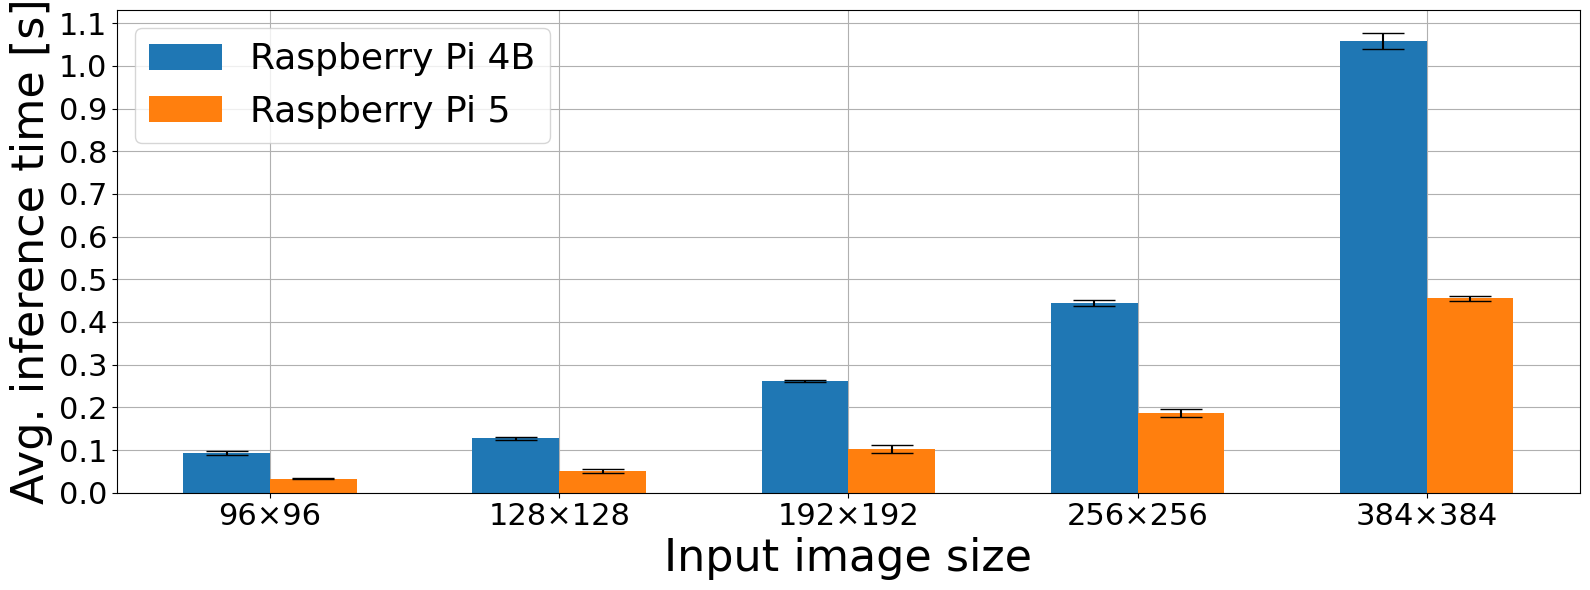

In [116]:
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

X = ['96×96', '128×128', '192×192', '256×256', '384×384']

X_axis = np.arange(len(X))
Y_axis = np.round(np.arange(0, 1.2, 0.1), 1)

width = 0.3
ax.bar(X_axis - width/2, rpi_4B_inference, width, label='Raspberry Pi 4B')
ax.errorbar(X_axis - width/2, rpi_4B_inference, yerr=rpi_4B_inference_std, fmt='none', ecolor='black', capsize=15)

ax.bar(X_axis + width/2, rpi_5_inference, width, label='Raspberry Pi 5')
ax.errorbar(X_axis + width/2, rpi_5_inference, yerr=rpi_5_inference_std, fmt='none', ecolor='black', capsize=15)
  
ax.set_xticks(X_axis, X, fontsize=22)
ax.set_yticks(Y_axis, Y_axis, fontsize=22) 
ax.set_xlabel('Input image size', fontsize=32) 
ax.set_ylabel('Avg. inference time [s]', fontsize=32)
ax.grid(True)
ax.set_axisbelow(True)
plt.legend(fontsize=26)
plt.tight_layout()
plt.show() 

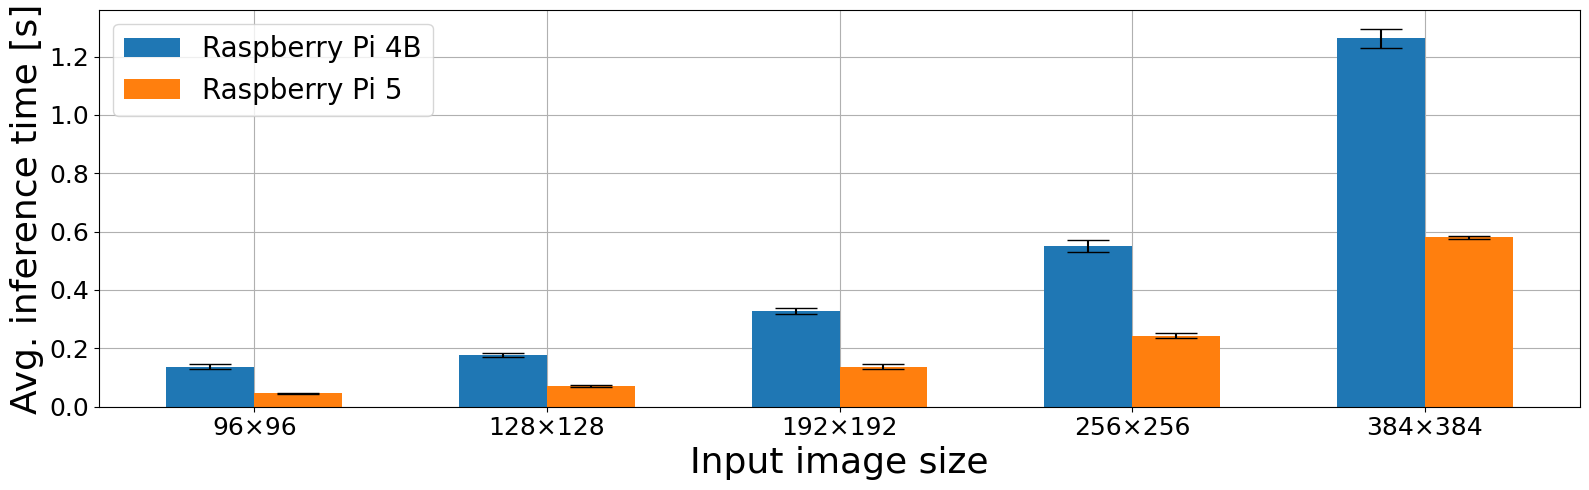

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(16, 5))

X = ['96×96', '128×128', '192×192', '256×256', '384×384']

X_axis = np.arange(len(X))
Y_axis = np.round(np.arange(0, 1.4, 0.2), 1)

width = 0.3
rpi_4B_process = np.array(rpi_4B_inference) + np.array(rpi_4B_preprocessing) + np.array(rpi_4B_sun_mask) + np.array(rpi_4B_irradiance_channel) + np.array(rpi_4B_cloud_channel) + np.array(rpi_4B_optical_flow)
yerr = np.array(rpi_4B_inference_std) + np.array(rpi_4B_preprocessing_std) + np.array(rpi_4B_sun_mask_std) + np.array(rpi_4B_irradiance_channel_std) + np.array(rpi_4B_cloud_channel_std) + np.array(rpi_4B_optical_flow_std)
ax.bar(X_axis - width/2, rpi_4B_process, width, label='Raspberry Pi 4B')
ax.errorbar(X_axis - width/2, rpi_4B_process, yerr=yerr, fmt='none', ecolor='black', capsize=15)

rpi_5_process = np.array(rpi_5_inference) + np.array(rpi_5_preprocessing) + np.array(rpi_5_sun_mask) + np.array(rpi_5_irradiance_channel) + np.array(rpi_5_cloud_channel) + np.array(rpi_5_optical_flow)
yerr = np.array(rpi_5_inference_std) + np.array(rpi_5_preprocessing_std) + np.array(rpi_5_sun_mask_std) + np.array(rpi_5_irradiance_channel_std) + np.array(rpi_5_cloud_channel_std) + np.array(rpi_5_optical_flow_std)
ax.bar(X_axis + width/2, rpi_5_process, width, label='Raspberry Pi 5')
ax.errorbar(X_axis + width/2, rpi_5_process, yerr=rpi_5_inference_std, fmt='none', ecolor='black', capsize=15)
  
ax.set_xticks(X_axis, X, fontsize=18)
ax.set_yticks(Y_axis, Y_axis, fontsize=18) 
ax.set_xlabel('Input image size', fontsize=26) 
ax.set_ylabel('Avg. inference time [s]', fontsize=26)
ax.grid(True)
ax.set_axisbelow(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()
# plt.savefig('process_times.pdf')

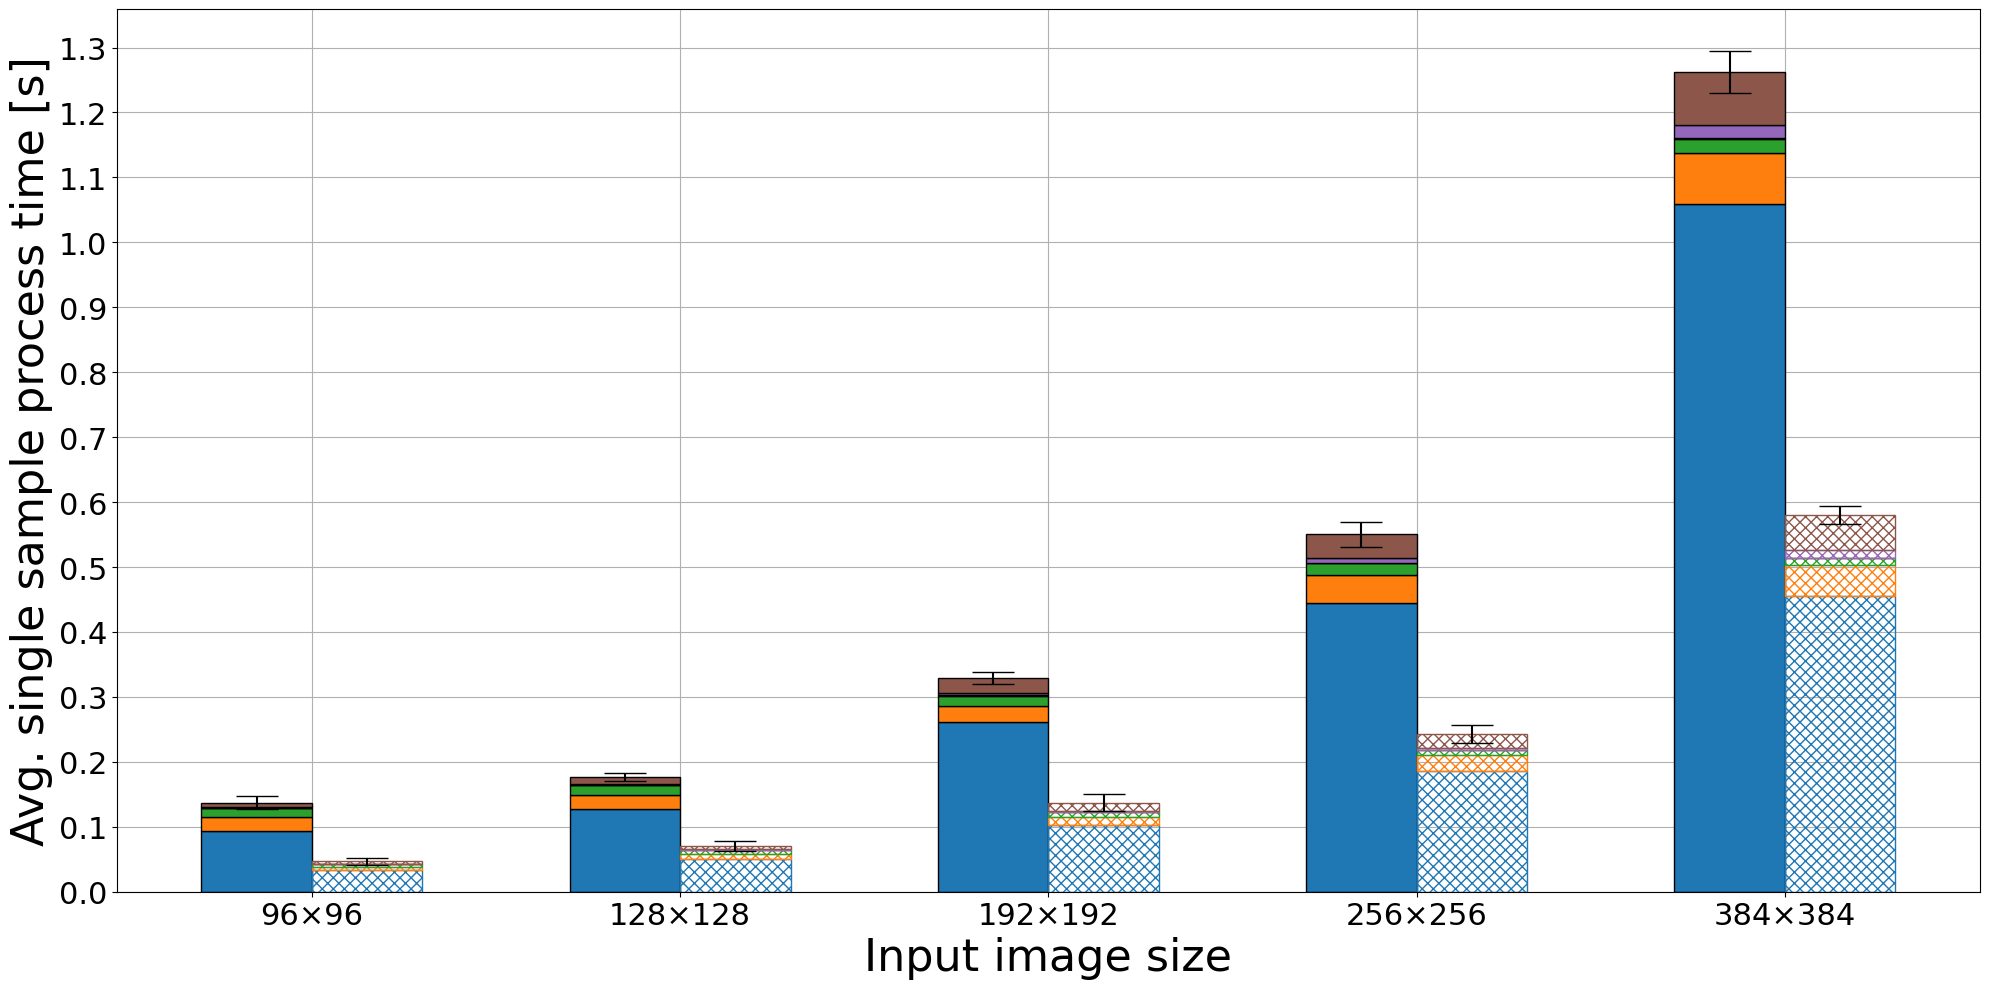

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

X = ['96×96', '128×128', '192×192', '256×256', '384×384']

X_axis = np.arange(len(X))
Y_axis = np.round(np.arange(0, 1.4, 0.1), 1)

width = 0.3

ax.bar(X_axis - width/2, rpi_4B_inference, width, label='Inference', edgecolor='black')
bottom = np.array(rpi_4B_inference)
ax.bar(X_axis - width/2, rpi_4B_preprocessing, width, label='Preprocessing', edgecolor='black', bottom=bottom)
bottom += np.array(rpi_4B_preprocessing)
ax.bar(X_axis - width/2, rpi_4B_sun_mask, width, label='Sun Mask', edgecolor='black', bottom=bottom)
bottom += np.array(rpi_4B_sun_mask)
ax.bar(X_axis - width/2, rpi_4B_irradiance_channel, width, label='Irradiance Channel', edgecolor='black', bottom=bottom)
bottom += np.array(rpi_4B_irradiance_channel)
ax.bar(X_axis - width/2, rpi_4B_cloud_channel, width, label='Cloud Channel', edgecolor='black', bottom=bottom)
bottom += np.array(rpi_4B_cloud_channel)
ax.bar(X_axis - width/2, rpi_4B_optical_flow, width, label='Optical Flow', edgecolor='black', bottom=bottom)

yerr = np.array(rpi_4B_inference_std) + np.array(rpi_4B_preprocessing_std) + np.array(rpi_4B_sun_mask_std) + np.array(rpi_4B_irradiance_channel_std) + np.array(rpi_4B_cloud_channel_std) + np.array(rpi_4B_optical_flow_std)
y = bottom + np.array(rpi_4B_optical_flow)
ax.errorbar(X_axis - width/2, y, yerr=yerr, fmt='none', ecolor='black', capsize=15)

ax.bar(X_axis + width/2, rpi_5_inference, width, label='Inference', hatch='xxx', fill=False, edgecolor='tab:blue')
bottom = np.array(rpi_5_inference)
ax.bar(X_axis + width/2, rpi_5_preprocessing, width, label='Preprocessing', hatch='xxx', fill=False, edgecolor='tab:orange', bottom=bottom)
bottom += np.array(rpi_5_preprocessing)
ax.bar(X_axis + width/2, rpi_5_sun_mask, width, label='Sun Mask', hatch='xxx', fill=False, edgecolor='tab:green', bottom=bottom)
bottom += np.array(rpi_5_sun_mask)
ax.bar(X_axis + width/2, rpi_5_irradiance_channel, width, label='Irradiance Channel', hatch='xxx', fill=False, edgecolor='tab:red', bottom=bottom)
bottom += np.array(rpi_5_irradiance_channel)
ax.bar(X_axis + width/2, rpi_5_cloud_channel, width, label='Cloud Channel', hatch='xxx', fill=False, edgecolor='tab:purple', bottom=bottom)
bottom += np.array(rpi_5_cloud_channel)
ax.bar(X_axis + width/2, rpi_5_optical_flow, width, label='Optical Flow', hatch='xxx', fill=False, edgecolor='tab:brown', bottom=bottom)

yerr = np.array(rpi_5_inference_std) + np.array(rpi_5_preprocessing_std) + np.array(rpi_5_sun_mask_std) + np.array(rpi_5_irradiance_channel_std) + np.array(rpi_5_cloud_channel_std) + np.array(rpi_5_optical_flow_std)
y = bottom + np.array(rpi_5_optical_flow)
ax.errorbar(X_axis + width/2, y, yerr=yerr, fmt='none', ecolor='black', capsize=15)
  
ax.set_xticks(X_axis, X, fontsize=22)
ax.set_yticks(Y_axis, Y_axis, fontsize=22) 
ax.set_xlabel('Input image size', fontsize=32) 
ax.set_ylabel('Avg. single sample process time [s]', fontsize=32)
ax.grid(True)
ax.set_axisbelow(True)
# plt.legend(fontsize=26)
plt.tight_layout()
plt.show() 